In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

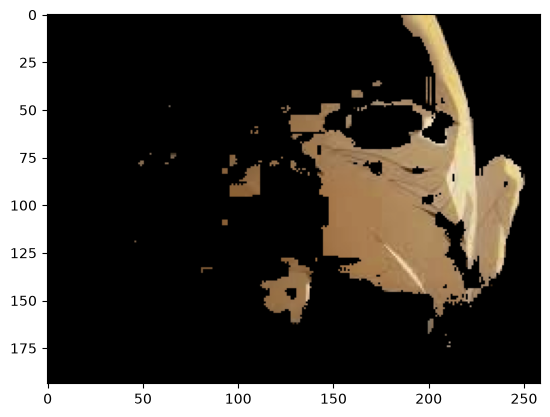

In [2]:
# segmentation techniques:
# global, adaptive, otsu thresholds
# canny edge detector (hysterisis thresholding)
# edge detectors
# region growing: just apply BFS and check for abs(current intensity - neighbor intensity) < threshold
#                 or any other factor for similarity
# color thresholding:

img = cv2.imread("Sukuna.jpg")

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

upper = np.array([60, 255, 255])
lower = np.array([15, 50, 50])

mask = cv2.inRange(img_hsv, lower, upper)

img_masked = cv2.bitwise_and(img_hsv, img_hsv, mask=mask)

plt.imshow(cv2.cvtColor(img_masked, cv2.COLOR_HSV2RGB))
plt.show()

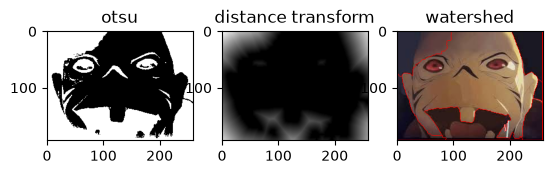

In [3]:
# watershed segmentation

# treats image as topographic map (high gradient == peaks), floods basins from markers, boundaries are where floods meet
# steps: gray -> otsu threshold -> opening (noise removal) -> sure background (dilate) -> sure foreground (distance transform threshold)
#        -> unknown = bg - fg -> label markers -> cv2.watershed (needs 3 channel BGR image, boundaries become -1)

img = cv2.imread("Sukuna.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# label sure regions 1..n, 0 is reserved for unknown
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws = img.copy()
markers = cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [0, 0, 255]  # boundaries (red in BGR)

plt.subplot(1, 3, 1)
plt.imshow(thresh, cmap="gray")
plt.title("otsu")
plt.subplot(1, 3, 2)
plt.imshow(dist_transform, cmap="gray")
plt.title("distance transform")
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB))
plt.title("watershed")
plt.show()

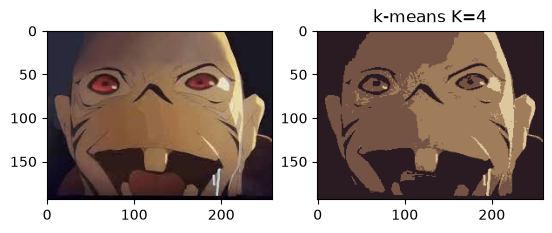

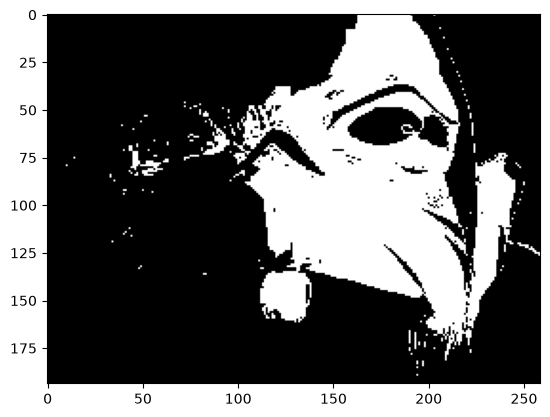

In [4]:
# clustering based segmentation: k-means

# each pixel is a feature vector (BGR, or LAB/HSV, optionally + x,y position)
# init k centroids -> assign every pixel to nearest centroid -> recompute centroids as mean -> repeat until convergence
# segmented image = every pixel replaced by its cluster centroid color

img = cv2.imread("Sukuna.jpg")

pixel_values = np.float32(img.reshape((-1, 3)))

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 4
# data, K, bestLabels, criteria, attempts, flags
compactness, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented = centers[labels.flatten()].reshape(img.shape)

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title(f"k-means K={K}")
plt.show()

# single cluster as a mask (e.g. cluster 0)
mask = (labels.flatten() == 0).reshape(img.shape[:2]).astype(np.uint8) * 255
plt.imshow(mask, cmap="gray")
plt.show()

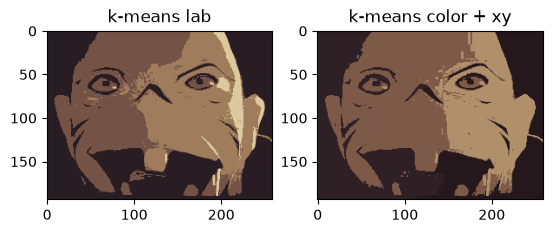

In [5]:
# k-means variants: lab color space (perceptually uniform, better for color clustering) and adding spatial features

img = cv2.imread("Sukuna.jpg")
h, w = img.shape[:2]

# lab
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
feats = np.float32(lab.reshape((-1, 3)))
_, labels, centers = cv2.kmeans(feats, 4, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
seg_lab = cv2.cvtColor(np.uint8(centers)[labels.flatten()].reshape(img.shape), cv2.COLOR_LAB2RGB)

# color + position (x, y scaled) -> spatially compact clusters
ys, xs = np.mgrid[0:h, 0:w]
alpha = 0.5
feats_xy = np.float32(np.dstack([img, alpha * xs, alpha * ys]).reshape((-1, 5)))
_, labels_xy, centers_xy = cv2.kmeans(feats_xy, 4, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
seg_xy = np.uint8(centers_xy[:, :3])[labels_xy.flatten()].reshape(img.shape)

plt.subplot(1, 2, 1)
plt.imshow(seg_lab)
plt.title("k-means lab")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(seg_xy, cv2.COLOR_BGR2RGB))
plt.title("k-means color + xy")
plt.show()

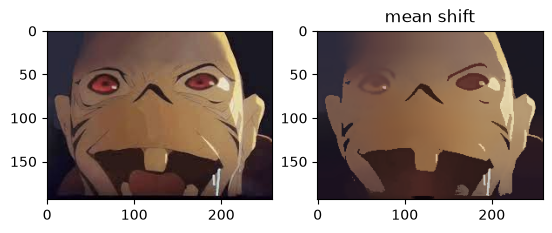

In [6]:
# mean shift (no K needed). cv2.pyrMeanShiftFiltering(src, sp, sr): sp = spatial window radius, sr = color window radius
# flattens regions of similar color, then every plateau is a segment

img = cv2.imread("Sukuna.jpg")

shifted = cv2.pyrMeanShiftFiltering(img, sp=21, sr=51)

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(shifted, cv2.COLOR_BGR2RGB))
plt.title("mean shift")
plt.show()

# DBSCAN would need sklearn (from sklearn.cluster import DBSCAN, MeanShift, KMeans) -> uv add scikit-learn

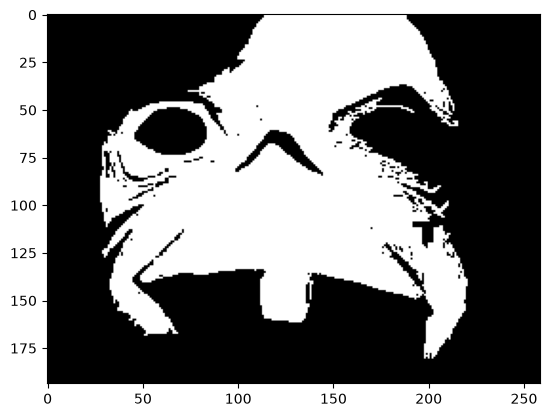

In [7]:
# region growing (BFS version, in case it's asked again)

def region_growing(image, seed, threshold):
    from collections import deque
    mask = np.zeros_like(image, dtype=np.uint8)
    seed_intensity = int(image[seed])
    q = deque([seed])
    while q:
        x, y = q.popleft()
        if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
            continue
        if mask[x, y] == 0 and abs(int(image[x, y]) - seed_intensity) < threshold:
            mask[x, y] = 255
            q.extend([(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)])
    return mask

img_gray = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)
seed = (img_gray.shape[0] // 2, img_gray.shape[1] // 2)
plt.imshow(region_growing(img_gray, seed, 30), cmap="gray")
plt.show()

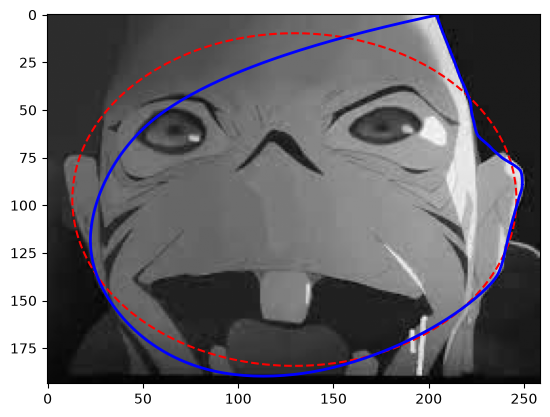

In [8]:
# active contour models (snakes): deformable curve that moves to minimise energy (smoothness + edge attraction)
# skimage.segmentation.active_contour(image, snake, alpha, beta, gamma)
#   alpha: elasticity (length), beta: rigidity (smoothness), w_line/w_edge: attraction to bright/edges

from skimage.segmentation import active_contour
from skimage.filters import gaussian

img = cv2.imread("Sukuna.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# initial circle around the centre of the image
s = np.linspace(0, 2 * np.pi, 400)
r = h / 2 + h / 2 * np.sin(s) * 0.9
c = w / 2 + w / 2 * np.cos(s) * 0.9
init = np.array([r, c]).T

snake = active_contour(gaussian(gray, sigma=3), init, alpha=0.015, beta=10, gamma=0.001)

plt.imshow(gray, cmap="gray")
plt.plot(init[:, 1], init[:, 0], "--r")
plt.plot(snake[:, 1], snake[:, 0], "-b", lw=2)
plt.show()

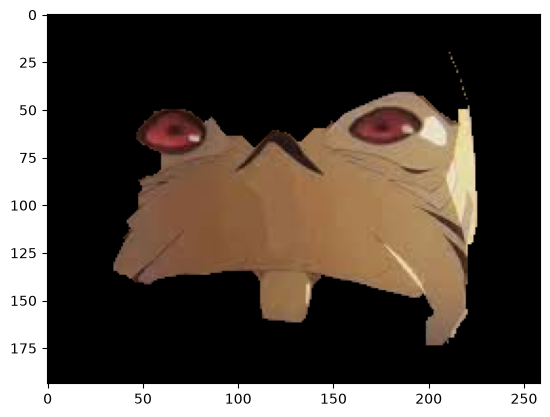

In [9]:
# grabcut: not in the manual but is a classic segmentation function. rect = (x, y, w, h) around the object

img = cv2.imread("Sukuna.jpg")
mask = np.zeros(img.shape[:2], np.uint8)
bgd = np.zeros((1, 65), np.float64)
fgd = np.zeros((1, 65), np.float64)

h, w = img.shape[:2]
rect = (int(w * 0.1), int(h * 0.1), int(w * 0.8), int(h * 0.8))

cv2.grabCut(img, mask, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

plt.imshow(cv2.cvtColor(img * fg_mask[:, :, None], cv2.COLOR_BGR2RGB))
plt.show()